In [1]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os

from CODES.modeling import create_seismic_model,plot_seismic_model

from parameters_py.config import (
					MODEL_NAME,FOLDER_OUTPUT,DEPTH_RANGES,S_VELOCITY_RANGES,VPVS_RANGES,NUMBER_LAYERS,
                    NX,NZ,DX,DZ,S_VELOCITY_BASEMENT,VPVS_BASEMENT,MAX_TOTAL,SEED,MAX_TOTAL
				   )

Reading configuration file: ./config_file.cnf


# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [2]:
data_path = FOLDER_OUTPUT+MODEL_NAME+'/DATA/'

### Directory for saving figures: 

In [3]:
figures_path = FOLDER_OUTPUT+MODEL_NAME+'/FIGURES/'

In [4]:
# Creating directories: 
os.makedirs(data_path,exist_ok=True)
os.makedirs(figures_path,exist_ok=True)

----

# The model will be created by the **Xarray** (https://docs.xarray.dev/en/stable/)
### Xarray is an open source project and Python package that introduces labels in the form of dimensions, 
### coordinates, and attributes on top of raw NumPy-like arrays, which allows for more intuitive, more concise, 
### and less error-prone user experience.

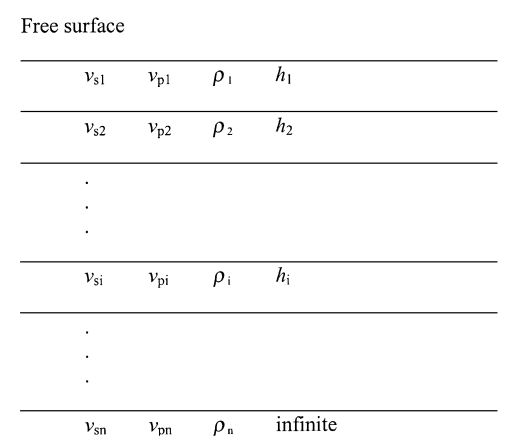

# **Examples of models**: 

Four different models were adopted to represent soil compaction in terms of density.  
1. The model without compaction (**MWC**) was used as a reference, presenting the normal density variation in the layers.
2. The **MCP1** model simulated compaction in the first layer, characterized by a higher of this layer.
3. The **MCP2-1** model considered compaction in the second layer with lateral density variation,
4. the **MCP2-2** model represented compaction in the second layer without lateral variation.

This approach allowed exploring different soil compaction scenarios and analyzing how these configurations impact the dispersion of surface waves, contributing to the identification and detailed characterization of compaction in agricultural soils. 

### Layers of the Model:
- Number of layers: 3 horizontal layers
- Layer depths: Randomly selected from a predefined list of tuples

-------------

### Grid Parameters:

As the layers are horizontal, there is no needed to over sampling.

- Profile length: 100 meters

---------------

In [5]:
model = create_seismic_model(depth_ranges=DEPTH_RANGES,vs_ranges=S_VELOCITY_RANGES,vpvs_ranges=VPVS_RANGES,num_layers=NUMBER_LAYERS,max_total=MAX_TOTAL,DX=DX,DZ=DZ,NX=NX,NZ=NZ,basement_vs=S_VELOCITY_BASEMENT,basement_vpvs=VPVS_BASEMENT,seed=SEED)

In [6]:
model

<xarray.Dataset> Size: 970kB
Dimensions:    (x: 1200, z: 20)
Coordinates:
    distance   (x) float64 10kB 0.0 0.1001 0.2002 0.3003 ... 119.8 119.9 120.0
    depth      (z) float64 160B 0.0 0.1053 0.2105 0.3158 ... 1.789 1.895 2.0
Dimensions without coordinates: x, z
Data variables:
    vp         (z, x) float64 192kB 1.157e+03 1.157e+03 ... 1.6e+03 1.6e+03
    vs         (z, x) float64 192kB 237.0 237.0 237.0 ... 800.0 800.0 800.0
    vpvs       (z, x) float64 192kB 4.88 4.88 4.88 4.88 4.88 ... 2.0 2.0 2.0 2.0
    density    (z, x) float64 192kB 1.386 1.386 1.386 ... 1.697 1.697 1.697
    formation  (z, x) int64 192kB 1 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    DX:                      0.1
    DZ:                      0.1
    NX:                      1200
    NZ:                      20
    num_layers:              3
    vs_per_layer_m_s:        [237, 520, 327]
    vp_per_layer_m_s:        [1156.56, 1206.3999999999999, 1219.71]
    density_per_layer_gcm3:  [1.3861145032395439, 1.4259534250656936, 1.43636...
    basement_vp_m_s:         [1600.]
    basement_vs_m_s:         800.0
    basement_vpvs:           2.0
    basement_density_g_cm3:  [1.69711661]

### Ploting 2D profile created:

In [7]:
model.vpvs[:,0]

<xarray.DataArray 'vpvs' (z: 20)> Size: 160B
array([4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.32, 2.32, 3.73, 3.73,
       3.73, 3.73, 3.73, 3.73, 2.  , 2.  , 2.  , 2.  , 2.  ])
Coordinates:
    distance  float64 8B 0.0
    depth     (z) float64 160B 0.0 0.1053 0.2105 0.3158 ... 1.789 1.895 2.0
Dimensions without coordinates: z
Attributes:
    units:      -
    long_name:  Vp/Vs ratio

In [8]:
model.vp[:,0]

<xarray.DataArray 'vp' (z: 20)> Size: 160B
array([1156.56, 1156.56, 1156.56, 1156.56, 1206.4 , 1206.4 , 1206.4 ,
       1206.4 , 1206.4 , 1219.71, 1219.71, 1219.71, 1219.71, 1219.71,
       1219.71, 1600.  , 1600.  , 1600.  , 1600.  , 1600.  ])
Coordinates:
    distance  float64 8B 0.0
    depth     (z) float64 160B 0.0 0.1053 0.2105 0.3158 ... 1.789 1.895 2.0
Dimensions without coordinates: z
Attributes:
    units:      m/s
    long_name:  P-wave velocity

In [9]:
model.vs[:,0]

<xarray.DataArray 'vs' (z: 20)> Size: 160B
array([237., 237., 237., 237., 520., 520., 520., 520., 520., 327., 327.,
       327., 327., 327., 327., 800., 800., 800., 800., 800.])
Coordinates:
    distance  float64 8B 0.0
    depth     (z) float64 160B 0.0 0.1053 0.2105 0.3158 ... 1.789 1.895 2.0
Dimensions without coordinates: z
Attributes:
    units:      m/s
    long_name:  S-wave velocity

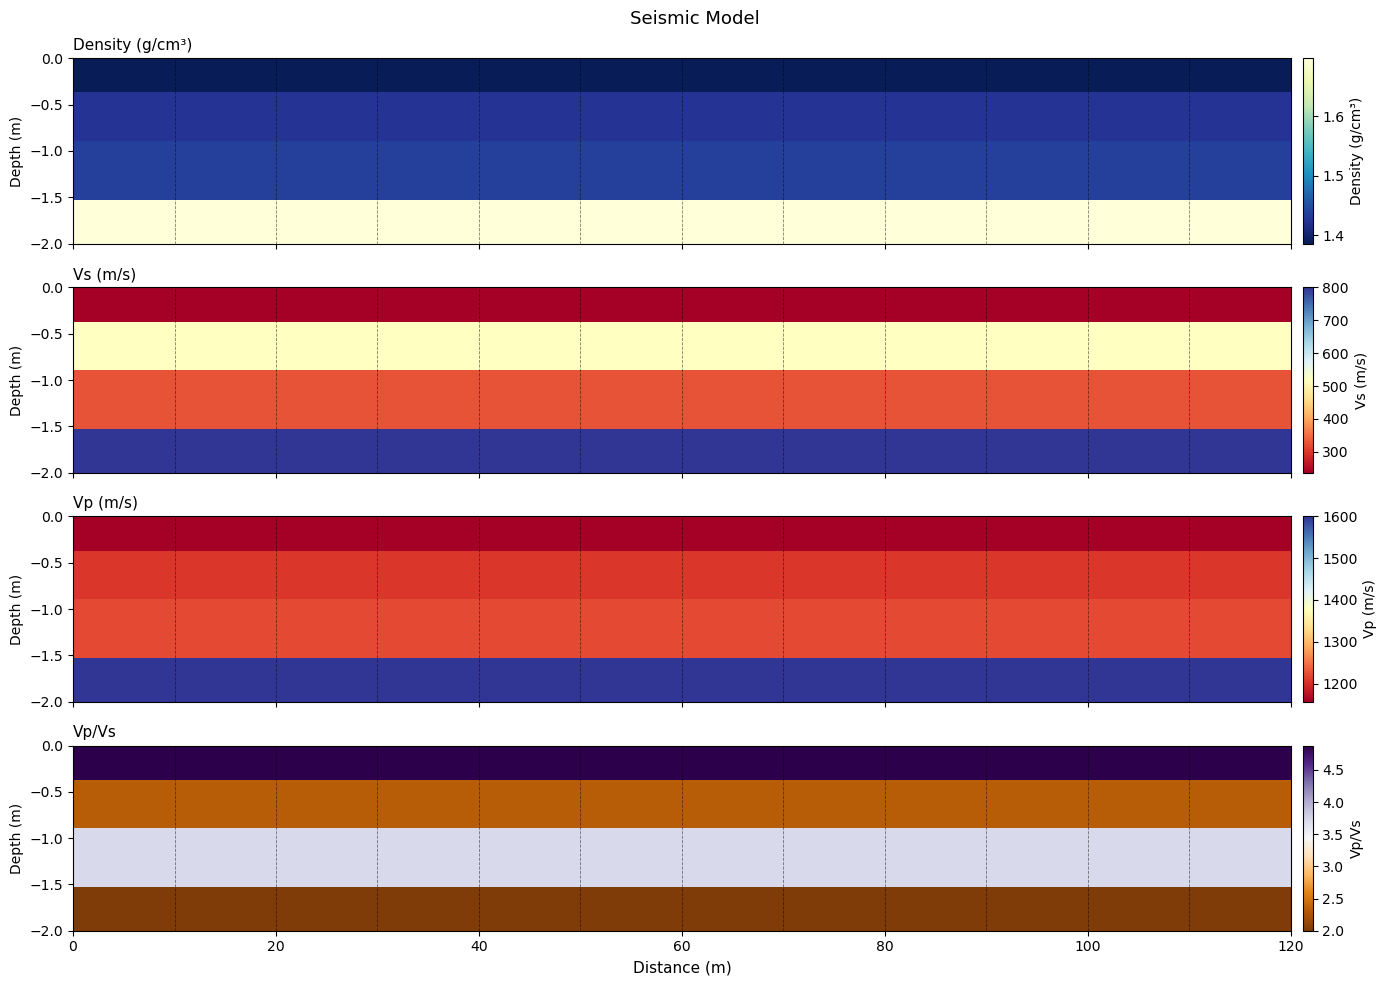

In [10]:
plot_seismic_model(model,path_output=figures_path+'model.png')

### Saving the 2D profile created:

In [11]:
model.to_zarr(data_path+"seismic_model.zarr", mode="w")

/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
